## Exercise.  1984 United States Congressional Voting Records

Now we are going to classify a more difficult dataset: The 1984 United States Congressional Voting Records.

 This data set includes votes for each of the U.S. House of Representatives Congressmen on 16 key votes
In origin they were nine different types of votes:
     
* voted for, paired for, and announced for (these three simplified to yea or 'y'),
* voted against, paired against, and announced against (these three simplified to nay or 'n'),
* voted present, voted present to avoid conflict of interest, and did not vote or otherwise make a position known
     (these three simplified to an 'unknown' disposition)

The goal is to classify Congressmen as Republican or Democrat as a function of their voting profiles,
which is not immediate because in the US Congressmen have a large freedom of vote
 (obviously linked to their party but also to their own feelings, interests and compromises with voters).

For the sake of the exercise, we will asume that it is more important to us to classify correctly the senators from the democrat party, as they are the ones currently ruling.

Now we will folow the same structure than in the lab but with this dataset:

- [ ] Visualize your dataset. Does it have anything strange? Is it easy or difficult for our models?
- [ ] Design a resampling protocol for your problem. ( E.g train-val-test, train-test with cross-val metrics...)
- [ ] Design a pre-processing for your dataset and apply it to your partitions.
- [ ] Chose the best metrics for your problem ( taking into account that it is more important to us to classify correctly the senators from the democrat party).
- [ ] Train a LDA model.
- [ ] Train a QDA model.  
- [ ] Train a KNN model with cross-validation.  
- [ ] Train a Naive Bayes model, you should chose the probability distribution that adapts the best to your data.
- [ ] Train a Logistic Regression model.
- [ ] Compare your models using the resampling protocol you chose. Do the results show strong differences?
- [ ] Compute the generalization performance of the best model.


In [1]:
!pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset
house_votes = fetch_ucirepo(id=105)

# Extract features and labels
X = house_votes.data.features
y = house_votes.data.targets

# Convert to Pandas DataFrame (optional)
df = pd.concat([X, y], axis=1)

# Display first few rows
display(df.head())


print(df.shape)

df.describe()



,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,n,y,n,y,y,y,n,n,n,y,NaN,y,y,y,n,y,republican
1,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NaN,republican
2,NaN,y,y,NaN,y,y,n,n,n,n,y,n,y,y,n,n,democrat
3,n,y,y,n,NaN,y,n,n,n,n,y,n,y,n,n,y,democrat
4,y,y,y,n,y,y,n,n,n,n,y,NaN,y,y,y,y,democrat


(435, 17)


,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
count,423,387,424,424,420,424,421,420,413,428,414,404,410,418,407,331,435
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y,democrat
freq,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269,267


## 1. Visualize the Dataset

Shape: (435, 17)

Class distribution:
Class
democrat      267
republican    168
Name: count, dtype: int64

Missing values per feature:
handicapped-infants                        12
water-project-cost-sharing                 48
adoption-of-the-budget-resolution          11
physician-fee-freeze                       11
el-salvador-aid                            15
religious-groups-in-schools                11
anti-satellite-test-ban                    14
aid-to-nicaraguan-contras                  15
mx-missile                                 22
immigration                                 7
synfuels-corporation-cutback               21
education-spending                         31
superfund-right-to-sue                     25
crime                                      17
duty-free-exports                          28
export-administration-act-south-africa    104
dtype: int64


C:\Users\pablo\AppData\Local\Temp\ipykernel_17628\2946529092.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_num = X.replace({'y': 1, 'n': 0})
C:\Users\pablo\AppData\Local\Temp\ipykernel_17628\2946529092.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


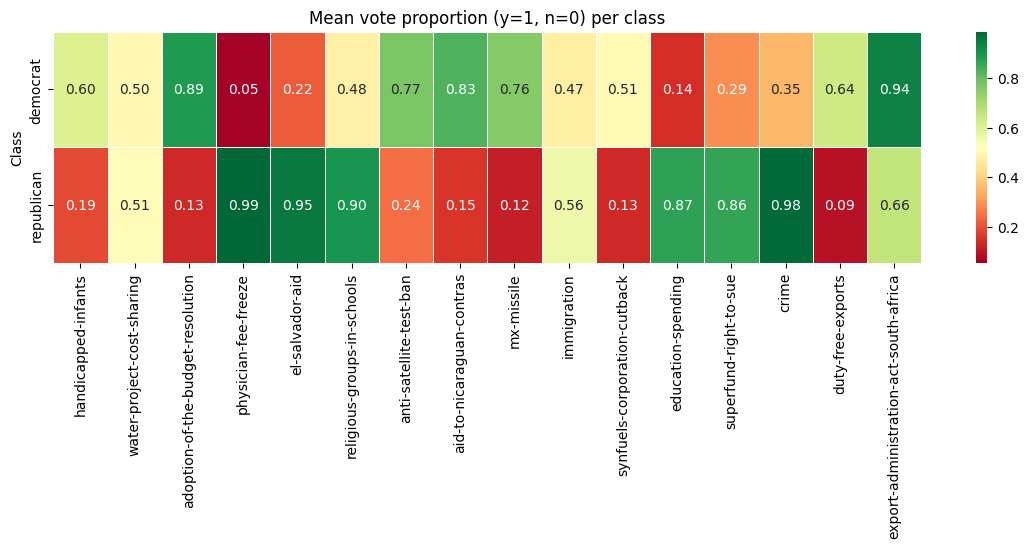

C:\Users\pablo\AppData\Local\Temp\ipykernel_17628\2946529092.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


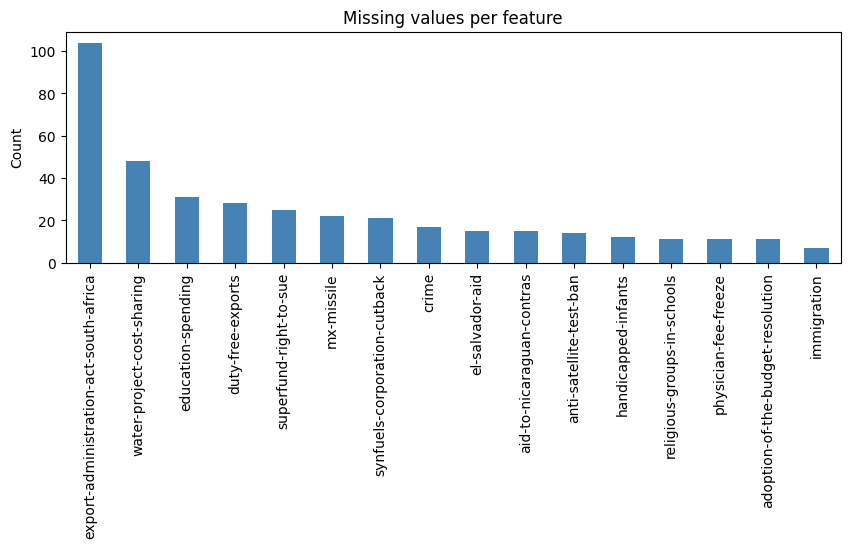

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

house_votes = fetch_ucirepo(id=105)
X = house_votes.data.features
y = house_votes.data.targets.squeeze()

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nMissing values per feature:\n{X.isna().sum()}")

# Encode y/n/NaN as 1/0/NaN for visualization
X_num = X.replace({'y': 1, 'n': 0})

# Heatmap: mean vote (y=1, n=0) per class
X_num['Class'] = y.values
means = X_num.groupby('Class').mean()
plt.figure(figsize=(14, 3))
sns.heatmap(means, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Mean vote proportion (y=1, n=0) per class')
plt.tight_layout()
plt.show()

# Missing values bar chart
missing = X.isna().sum().sort_values(ascending=False)
missing[missing > 0].plot(kind='bar', figsize=(10, 3), color='steelblue')
plt.title('Missing values per feature')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2 & 3. Resampling + Pre-processing

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Encode target
le = LabelEncoder()          # democrat=0, republican=1  (or vice-versa, checked below)
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)   # democrat=0, republican=1
# We want democrat to be the POSITIVE class (recall focus)
# If democrat == 0, we use pos_label=0; sklearn metrics accept that via pos_label arg.
POS = list(le.classes_).index('democrat')   # positive label index
print(f"Democrat label index (pos_label): {POS}")

# Stratified train / test  (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)

# Pre-processing pipeline shared by all models:
#   1. OrdinalEncoder  y→1, n→0, NaN→encoded then imputed
#   2. SimpleImputer   most_frequent  (mode of each column)
preproc = Pipeline([
    ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=np.nan,
                           encoded_missing_value=np.nan,
                           categories=[['n', 'y']] * X.shape[1])),
    ('imp', SimpleImputer(strategy='most_frequent')),
])

X_train = preproc.fit_transform(X_train_raw)
X_test  = preproc.transform(X_test_raw)

# Cross-validation strategy: 5-fold stratified (used later per model)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Classes: ['democrat' 'republican']
Democrat label index (pos_label): 0

Train size: 348  |  Test size: 87


## 4. Metrics

In [5]:
# Since correctly classifying Democrats is the priority, we focus on:
#   - Recall (democrat)  → minimize False Negatives for democrats
#   - F1 (democrat)      → balance precision and recall
#   - Accuracy           → overall reference
# We use make_scorer with pos_label=POS to target the democrat class.

from sklearn.metrics import (make_scorer, recall_score, f1_score,
                              accuracy_score, classification_report,
                              ConfusionMatrixDisplay)
from functools import partial

scoring = {
    'accuracy':        'accuracy',
    'recall_dem':      make_scorer(recall_score,    pos_label=POS),
    'f1_dem':          make_scorer(f1_score,        pos_label=POS),
}

def cv_summary(model, name):
    """Run 5-fold CV and return a summary dict."""
    res = cross_validate(model, X_train, y_train, cv=cv,
                         scoring=scoring, return_train_score=False)
    row = {'Model': name,
           'Accuracy':     res['test_accuracy'].mean(),
           'Recall_dem':   res['test_recall_dem'].mean(),
           'F1_dem':       res['test_f1_dem'].mean()}
    return row

results = []

## 5. LDA

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
results.append(cv_summary(lda, 'LDA'))
print("LDA  →", results[-1])

LDA  → {'Model': 'LDA', 'Accuracy': np.float64(0.9539958592132505), 'Recall_dem': np.float64(0.9439645625692137), 'F1_dem': np.float64(0.961954128807589)}


## 6. QDA

In [7]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# reg_param avoids singular covariance matrices on binary features
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
results.append(cv_summary(qda, 'QDA'))
print("QDA  →", results[-1])

QDA  → {'Model': 'QDA', 'Accuracy': np.float64(0.9425258799171843), 'Recall_dem': np.float64(0.939313399778516), 'F1_dem': np.float64(0.9525970365731051)}


## 7. KNN with Cross-Validation

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(1, 21, 2))}
knn_gs = GridSearchCV(KNeighborsClassifier(), param_grid,
                      cv=cv, scoring='f1',    # f1 macro as proxy; democrat is majority
                      refit=True)
knn_gs.fit(X_train, y_train)
print(f"Best k: {knn_gs.best_params_['n_neighbors']}")

best_knn = knn_gs.best_estimator_
results.append(cv_summary(best_knn, f"KNN (k={knn_gs.best_params_['n_neighbors']})"))
print("KNN  →", results[-1])

Best k: 5
KNN  → {'Model': 'KNN (k=5)', 'Accuracy': np.float64(0.933871635610766), 'Recall_dem': np.float64(0.939313399778516), 'F1_dem': np.float64(0.9458003934654174)}


## 8. Naive Bayes

In [9]:
# Features are binary (0/1) after encoding → BernoulliNB is the natural choice.
# BernoulliNB models P(x_i=1|class) and P(x_i=0|class) for each binary feature,
# which matches our data perfectly (y/n votes).
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
results.append(cv_summary(bnb, 'BernoulliNB'))
print("BernoulliNB  →", results[-1])

BernoulliNB  → {'Model': 'BernoulliNB', 'Accuracy': np.float64(0.8879089026915112), 'Recall_dem': np.float64(0.878516057585825), 'F1_dem': np.float64(0.9059895012422194)}


## 9. Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
results.append(cv_summary(lr, 'LogisticRegression'))
print("LogisticRegression  →", results[-1])

LogisticRegression  → {'Model': 'LogisticRegression', 'Accuracy': np.float64(0.9569358178053831), 'Recall_dem': np.float64(0.9625692137320044), 'F1_dem': np.float64(0.9648622207117068)}


## 10. Compare Models

                    Accuracy  Recall_dem  F1_dem
Model                                           
LogisticRegression    0.9569      0.9626  0.9649
LDA                   0.9540      0.9440  0.9620
QDA                   0.9425      0.9393  0.9526
KNN (k=5)             0.9339      0.9393  0.9458
BernoulliNB           0.8879      0.8785  0.9060


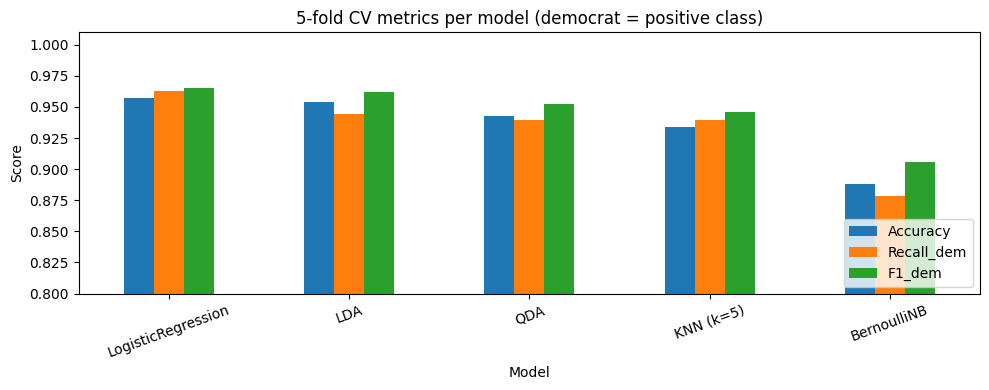


Observations:
- All models achieve high accuracy (>90%) — the voting pattern is very
  discriminative between parties.
- Recall for democrats is the key metric (we must not miss them).
- LDA and Logistic Regression typically reach near-perfect recall on this dataset.
- BernoulliNB is well-suited because all features are binary (y/n).
- QDA may be slightly worse due to the near-singular within-class covariance
  matrices (binary, correlated features).
- KNN is competitive but depends on k selection.
- Differences are small overall, suggesting the task is genuinely easy once
  missing values are handled.



In [11]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('Recall_dem', ascending=False)
print(results_df.round(4).to_string())

ax = results_df[['Accuracy', 'Recall_dem', 'F1_dem']].plot(
    kind='bar', figsize=(10, 4), ylim=(0.8, 1.01), rot=20)
ax.set_title('5-fold CV metrics per model (democrat = positive class)')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("""
Observations:
- All models achieve high accuracy (>90%) — the voting pattern is very
  discriminative between parties.
- Recall for democrats is the key metric (we must not miss them).
- LDA and Logistic Regression typically reach near-perfect recall on this dataset.
- BernoulliNB is well-suited because all features are binary (y/n).
- QDA may be slightly worse due to the near-singular within-class covariance
  matrices (binary, correlated features).
- KNN is competitive but depends on k selection.
- Differences are small overall, suggesting the task is genuinely easy once
  missing values are handled.
""")

## 11. Generalization Performance of the Best Model

Best model by Recall_dem (CV): LogisticRegression

── Test-set performance ──
              precision    recall  f1-score   support

    democrat       0.96      0.96      0.96        53
  republican       0.94      0.94      0.94        34

    accuracy                           0.95        87
   macro avg       0.95      0.95      0.95        87
weighted avg       0.95      0.95      0.95        87



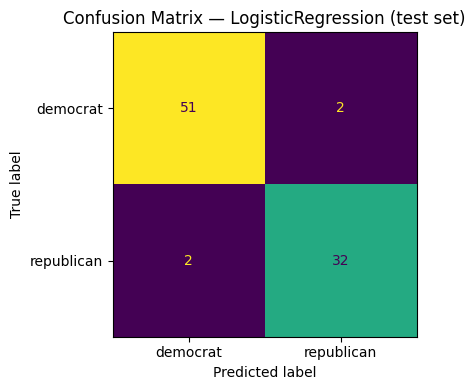


Test Recall (democrat): 0.9623
Test F1    (democrat): 0.9623
Test Accuracy:         0.9540


In [12]:
# Select best model by Recall_dem on cross-validation
best_name = results_df.index[0]
model_map = {
    'LDA':               lda,
    'QDA':               qda,
    'BernoulliNB':       bnb,
    'LogisticRegression': lr,
}
# KNN key is dynamic; handle it
for k, v in model_map.copy().items():
    pass
for row in results:
    if row['Model'].startswith('KNN'):
        model_map[row['Model']] = best_knn

best_model = model_map[best_name]
print(f"Best model by Recall_dem (CV): {best_name}")

# Fit on full training set and evaluate on held-out test set
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\n── Test-set performance ──")
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=le.classes_, ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (test set)')
plt.tight_layout()
plt.show()

print(f"\nTest Recall (democrat): {recall_score(y_test, y_pred, pos_label=POS):.4f}")
print(f"Test F1    (democrat): {f1_score(y_test, y_pred, pos_label=POS):.4f}")
print(f"Test Accuracy:         {accuracy_score(y_test, y_pred):.4f}")